# 2.4 · LGD results

*2. Experiment 2 · notebook 2.4 of the story.* ← [2.3 · PD results](<2.3_pd_results.ipynb>) · (end of the story) →

**The benchmark — the experiment's answer.** The 60 Experiment 2 arms and the shared reference
models (the released TabICLv2, TabPFN-3, CatBoost, linear regression), all scored by the same code on the
same splits, read from `output/results/lgd/eval/`. **Not all of them see the same data.** Our
arms and the released TabICLv2 see at most 1,024 context rows — the table size our arms trained
on — drawn at random (`TabICLBaseline._cap_context`); TabPFN-3 sees up to 10,000 rows, in proportion;
CatBoost and linear regression train on every row; the foundation models see at most 500 features
(`src/eval/baselines.py`). So our arms against the released TabICLv2 is a matched comparison,
and every other reference had more data. The training-time view
of the same arms is [2.2 · LGD fine-tuning](<2.2_lgd_finetuning.ipynb>), whose introduction explains how an arm is named.

**Status: the benchmark has not run yet.** It runs once every arm of the track has trained, so each
figure below is a one-line placeholder until then and fills in when the results exist; the notebook
can be run at any time.

**Two questions, in the protocol's order** (`docs/EXPERIMENTAL_DESIGN.md` §5). **A** — which
configuration does the development split select? It is the only data a prior may be chosen on.
**B** — how does it do on the holdout? Untouched until the end, it is what gets reported. Choosing on
the holdout would invalidate the experiment. **C** then shows every dataset on both sides of the split
and **D** says why there is no LGD literature landscape.

**Reading the metrics.** R² and RMSE measure the point prediction; pinball loss and CRPS score the whole predicted distribution; interval coverage says whether its intervals are honest; the boundary-mass error says whether the atoms at 0 and 1 are predicted in the right amount. Our nano-scale arms are expected to trail the frontier
reference in absolute terms; the claim is the contrast between priors at matched compute, not state
of the art.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib
ROOT = pathlib.Path.cwd()
# Walk up to the repository root — the notebook may be opened from its chapter folder, from
# notebooks/, or from the root — then work FROM the root, so relative paths (config/...) resolve
# exactly as under `python -m src.utils.run_notebooks`.
while not (ROOT / "src" / "visualize").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.visualize import results_plots, figures, style, literature

style.apply()
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK = "lgd"
EXP = "exp2"
# Reads output/manifests/ and output/results/ — whatever the runs have written so far, so a
# partial sweep still renders. Constructing the saver clears THIS notebook's figure folder only.
FIGS = figures.FigureSaver("2.4_lgd_results")

## A · Which configuration does development select?

### A1 · Configurations ranked on the development datasets

**What it shows.** Every configuration's development R², averaged with equal weight per development dataset and then per training seed, sorted, one point per configuration marked by its prior mix, reference models in olive; the whisker is the standard deviation over training seeds. A configuration missing a development dataset is left out rather than rewarded for skipping a hard one (`src/eval/selection.py`).

**Why it matters.** The top of this ranking is the prior the next experiment inherits — the only selection the protocol allows.

**What it says.** Not run yet.

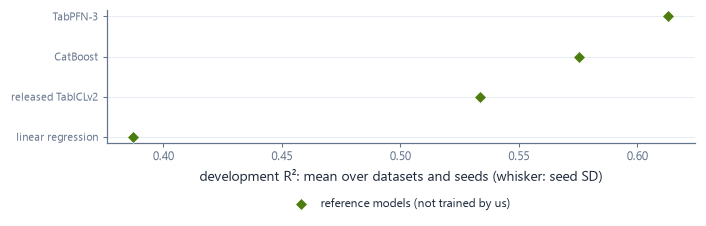

In [2]:
FIGS.save(results_plots.overall_ranking(TASK, exp=EXP), "overall_ranking",
    caption="Development R² per configuration, averaged over the development datasets and training seeds, one point per configuration marked by prior mix with reference models in olive, and whiskers for the training-seed standard deviation.");

## B · How does it do on the holdout?

The reported result: the same comparison on the holdout datasets, which no selection has seen.

### B1 · Credit prior against the control

**What it shows.** Every model's mean R² over the holdout datasets, one point per model, in one column per prior mix (0 % credit is the control) and one for the reference models, with a bar at each column's mean.

**Why it matters.** The figure the experiment exists for: does training on our prior beat training on TabICL's own, at the same compute, on data neither saw?

**What it says.** Not run yet.

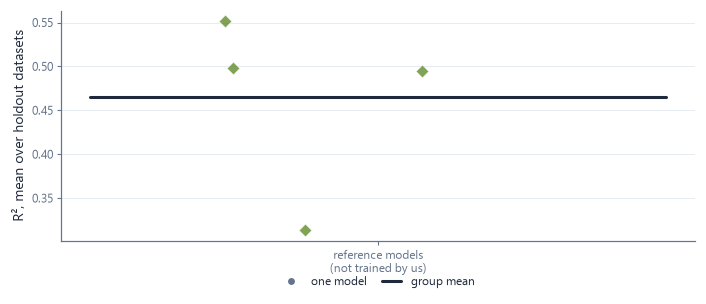

In [3]:
FIGS.save(results_plots.credit_vs_control(TASK, exp=EXP, role="holdout"), "credit_vs_control",
    caption="Per-model mean R² on the holdout datasets, one column per prior mix (0 % credit is the control) and one for the reference models, one point per model with a bar at each column mean.");

### B2 · Against the released reference

**What it shows.** Each trained arm's mean holdout R² minus that of the released TabICLv2, one bar per arm coloured by prior mix, with the reference at zero.

**Why it matters.** The released model was trained on orders of magnitude more compute; trailing it is expected and not the claim, but how far each arm trails is the scale of the result.

**What it says.** Not run yet.

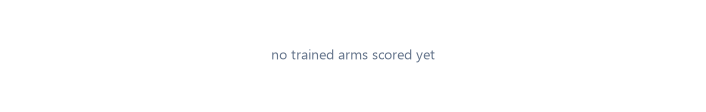

In [4]:
FIGS.save(results_plots.beats_reference(TASK, exp=EXP, role="holdout"), "beats_reference",
    caption="Each trained arm's mean R² on the holdout datasets minus the released TabICLv2's, one horizontal bar per arm coloured by prior mix, with a reference line at zero.");

### B3 · Every benchmark metric

**What it shows.** One panel per benchmark metric on the holdout datasets, one bar per prior mix and one for the reference models, each the mean of its models' means; each title carries the metric's goal, and a metric with a target value draws it dashed.

**Why it matters.** A prior that helps ranking but hurts calibration splits across these panels.

**What it says.** Not run yet.

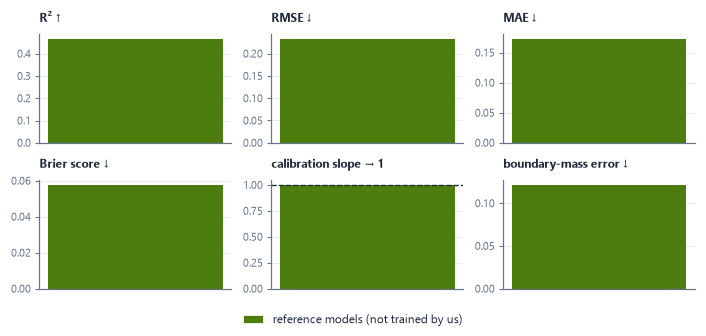

In [5]:
FIGS.save(results_plots.metric_grid(TASK, exp=EXP, role="holdout"), "metric_grid",
    caption="One panel per benchmark metric on the holdout datasets, one bar per prior mix and one for the reference models, each the mean of the models' means; each title marks the improving direction or target value.");

### B4 · Which fine-tuning lever moved the score?

**What it shows.** One panel per fine-tuning lever (credit fraction, freeze strategy, L2-SP, learning rate): the mean R² of every arm sharing each value.

**Why it matters.** Experiment 2's own question: given the prior, which way of adapting the released model works best.

**What it says.** Not run yet.

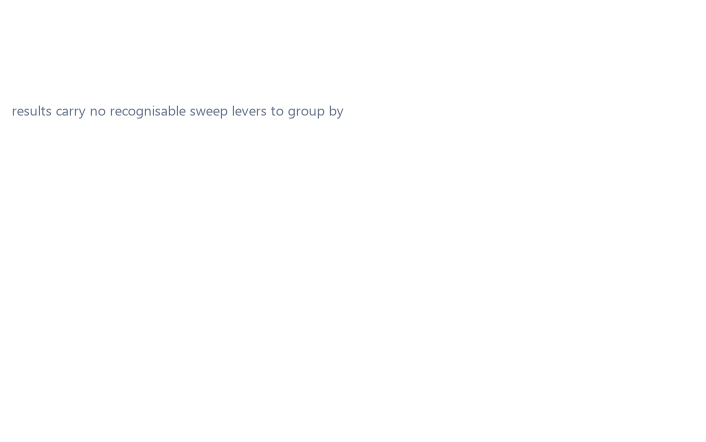

In [6]:
FIGS.save(results_plots.lever_effect(TASK, exp=EXP), "lever_effect",
    caption="Mean R² by the value of each fine-tuning lever, one panel per lever: prior mix, layers trained, L2-SP and learning rate.");

## C · Where does it hold?

No dataset hidden behind a mean: every dataset on both sides of the split, labelled with its side.

### C1 · Every dataset

**What it shows.** The best R² in each group on each real dataset — per prior mix and among the reference models, a model scored by its mean over evaluation seeds — as grouped bars, development datasets first, then holdout, each labelled with its side of the split.

**Why it matters.** A prior that wins on average by helping one easy dataset is exposed here.

**What it says.** Not run yet.

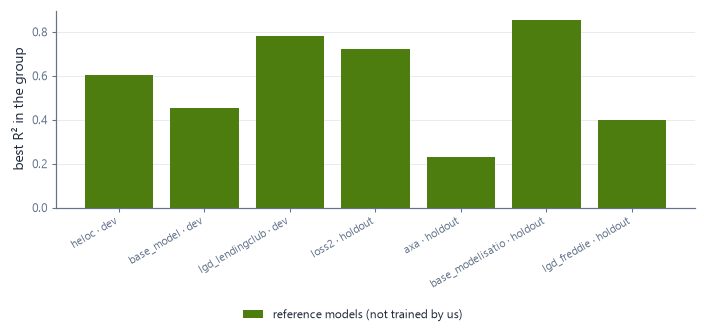

In [7]:
FIGS.save(results_plots.per_dataset(TASK, exp=EXP), "per_dataset",
    caption="Best R² per real dataset in each prior mix and among the reference models, a model scored by its mean over evaluation seeds, as grouped bars with development datasets first and then holdout.");

### C2 · The same, as one table

**What it shows.** The best R² in each group on each dataset as an annotated heatmap: datasets down the side (development first), the three prior mixes and the reference models across.

**Why it matters.** The whole pattern at a glance, with the numbers written in.

**What it says.** Not run yet.

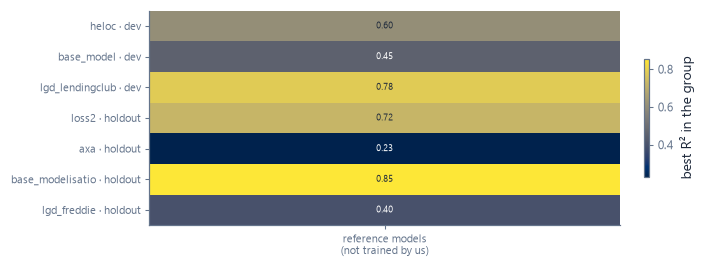

In [8]:
FIGS.save(results_plots.per_dataset_heatmap(TASK, exp=EXP), "per_dataset_heatmap",
    caption="Best R² in each prior mix and among the reference models on each dataset as an annotated heatmap, development datasets first and then holdout on the vertical axis.");

## D · Where the field sits

### D1 · There is no LGD landscape to draw

`tfm-library` holds no LGD result for a tabular foundation model — no R², pinball loss or CRPS on a
real loss-given-default dataset — and O'Prior, the one prior paper that supports regression, evaluates
only classification (`papers/2026/05_Bouadi_ShapingThePrior`). An LGD landscape would have to be made
of numbers from outside the library, which this project does not present as literature. The PD results
notebook draws the credit-domain ROC-AUC landscape.

## Summary

The benchmark in text: what development selects (A), then how it does on the holdout (B). Printed
last, in the order of the sections above, so `output/All_Results.md` carries the same story as this
notebook, followed by the `tfm-library` sources it cites (pin `e5ce016`) and the list of figures.

In [9]:
print(results_plots.results_summary(TASK, exp=EXP))
print()
print(literature.references_md(["crps", "quantiles", "oprior_scope"]))
print()
print(FIGS.summary())

EXP2 LGD RESULTS — the benchmark
  4 models on 7 datasets | metrics: r2, rmse, mae, brier, calibration_slope, boundary_mass_abs_err

A. WHICH PRIOR DEVELOPMENT SELECTS (R², development datasets, mean over datasets and seeds)
  0.6132  TabPFN-3
  0.5756  CatBoost
  0.5337  released TabICLv2
  0.3874  linear regression

B. HOW IT DOES ON THE HOLDOUT (R², holdout datasets, mean over every arm of each share)
  0.4952  reference: CatBoost
  0.5515  reference: TabPFN-3
  0.3135  reference: linear regression
  0.4983  reference: released TabICLv2

C. OUR CREDIT PRIOR AGAINST THE CONTROL — matched arms that differ only in the credit share
  (same filter and training seed; a positive difference means the credit prior helped)

References (tfm-library pin e5ce016):
  - SYNTHESIS.md; TabICLv2 §I.7  [editorial+paper]
  - papers/2026/02_Qu_TabICLv2 §I; NanoTabICLv2(out_dim=999)  [paper+code]
  - papers/2026/05_Bouadi_ShapingThePrior §benchmarks  [paper-evaluated]

2.4_lgd_results: 7 figures -> C:\Us